### Ensemble Methods

### Build a model that can predict Loan Approval status based on

### Business Objective: Build a model that can predict the status of Loan Approval on basis of many intermediate factors.

### Data Gathering

In [1]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/kavaderohan2005-netizen/Datasets/refs/heads/main/train_loan.csv")
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### Perform basic data quality checks

In [2]:
df.shape

(58645, 13)

In [3]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

### Separate X and Y Features

**Y : Loan Status**

    0-> Not Approved
    1-> Approved

In [5]:
X = df.drop(columns=['id','loan_status'])
Y = df[['loan_status']]

display(X.head())
print('--------------')
display(Y.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3


--------------


,loan_status
0,0
1,0
2,0
3,0
4,0


### Observe whether Y data is balanced or not.

**Meaning:** DO we have moderate datapoints for Class approved and Not approved(0,1)

In [6]:

Y['loan_status'].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

In [7]:
((Y['loan_status'].value_counts())/(len(df)))*100

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64

<Axes: ylabel='loan_status'>

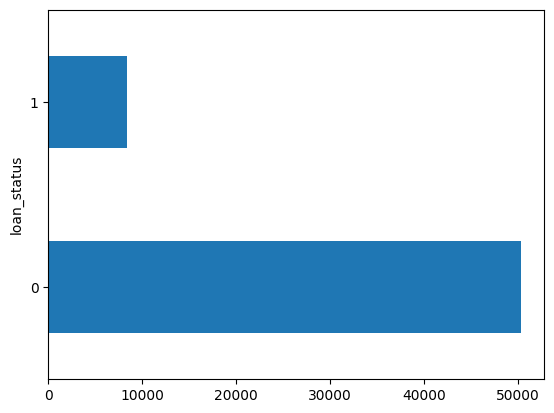

In [8]:
Y['loan_status'].value_counts().plot(kind='barh')

### The dataset is imbalanced in nature

### Technique 1: splitting the data on basis of stratified split

In [9]:
from sklearn.model_selection import train_test_split
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(X,Y,train_size=0.75,stratify=Y)

In [10]:
xtrain1.shape

(43983, 11)

In [11]:
ytrain1.shape

(43983, 1)

In [12]:
xtrain1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
20334,23,64500,MORTGAGE,0.0,DEBTCONSOLIDATION,C,4000,12.53,0.06,N,4
50388,24,60000,MORTGAGE,1.0,VENTURE,B,5000,10.36,0.08,N,4
44894,21,34000,RENT,5.0,VENTURE,D,8500,16.89,0.25,Y,3
54022,30,100000,MORTGAGE,11.0,EDUCATION,B,10000,11.49,0.10,N,6
21158,22,47000,RENT,1.0,EDUCATION,E,12600,17.99,0.26,N,3


In [13]:
xtest1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
40261,22,72000,RENT,6.0,DEBTCONSOLIDATION,C,8000,15.96,0.11,Y,3
39175,26,68000,RENT,3.0,EDUCATION,E,14000,17.99,0.20,Y,2
47794,23,30000,RENT,2.0,VENTURE,D,6000,14.96,0.20,N,2
25801,23,33996,RENT,3.0,PERSONAL,A,15000,6.17,0.44,N,3
47648,38,60000,RENT,2.0,DEBTCONSOLIDATION,B,6000,10.95,0.10,N,11


### Data Preprocessing and Data Cleaning

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns) 
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler())

cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore',sparse_output=False))

pre = ColumnTransformer([('cat',cat_pipe,cat),
                         ('con',num_pipe,con)]).set_output(transform='pandas')

pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [15]:
pre.fit(xtrain1)

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [16]:
xtrain1_pre = pre.transform(xtrain1)
xtest1_pre = pre.transform(xtest1)

In [17]:
xtrain1_pre.head(2)

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
20334,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.756749,0.009847,-1.188747,-0.941322,0.612813,-1.083289,-0.45063
50388,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,-0.590827,-0.107333,-0.937011,-0.760843,-0.101570,-0.865048,-0.45063


### Model Building

### Resampling Method

In [18]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


### Restart the kernel and run all the cells

    Resampling:

    1. Over sampling -> SMOTE , ADASYN SMOTE: Synthetic Minority Over sampling technique ADASYN : Adaptive Synthetic sample technique
    2. Under sampling

In [19]:
len(xtrain1_pre)

43983

In [22]:
ytrain1['loan_status'].value_counts()

loan_status
0    37721
1     6262
Name: count, dtype: int64

In [23]:
from imblearn.over_sampling import SMOTE,ADASYN

smote = SMOTE()

x_sampl,y_sampl = smote.fit_resample(xtrain1_pre,ytrain1)

In [24]:
len(x_sampl)

75442

In [25]:
len(y_sampl)

75442

In [26]:
y_sampl['loan_status'].value_counts()

loan_status
0    37721
1    37721
Name: count, dtype: int64

### Model Building using SMOTE sampling technique

In [27]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()

model2.fit(x_sampl,y_sampl)

e:\DATA SCIENTIST\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
model2.score(x_sampl,y_sampl)

0.8399432676758304

### Ensemble Methods

    Random Forest
    Gradient Boost

In [29]:
##
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

random_model = RandomForestClassifier(
    n_estimators=50, # number of estimators -> number of decision trees
    max_depth=5
)

gradient_model = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.01
)

In [30]:
random_model.fit(x_sampl,y_sampl['loan_status'])

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
random_model.score(x_sampl,y_sampl)

0.8623710930251054

In [32]:
random_model.score(xtest1_pre,ytest1)

0.9156322466239258

In [33]:
gradient_model.fit(x_sampl,y_sampl['loan_status'])

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [34]:
gradient_model.score(x_sampl,y_sampl)

0.873505474404178

In [35]:
gradient_model.score(xtest1_pre,ytest1)

0.9152230255081162

### Hyperparameter tuning

In [36]:
params = {
    'n_estimators':[50,80,100],
    'max_depth':[4,5,6,7]
}

base_random_model = RandomForestClassifier()

from sklearn.model_selection import RandomizedSearchCV
rscv1 = RandomizedSearchCV(estimator=base_random_model,param_distributions=params,cv=3,scoring='f1_macro')
rscv1.fit(x_sampl,y_sampl['loan_status'])

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [4, 5, ...], 'n_estimators': [50, 80, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [37]:
rscv1.best_params_

{'n_estimators': 100, 'max_depth': 7}

In [38]:
rscv1.best_score_

np.float64(0.8756148311859967)

In [39]:
best_random = rscv1.best_estimator_
best_random

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
best_random.score(x_sampl,y_sampl)

0.8782243312743565

In [41]:

best_random.score(xtest1_pre,ytest1)

0.9255217569226573

In [42]:
# for gradient descent
params2 = {
    'n_estimators':[50,80,100],
    'max_depth':[4,5,6,7],
    'learning_rate':[0.01,0.02,0.1,0.2]
}

base_gradient_model = GradientBoostingClassifier()

from sklearn.model_selection import RandomizedSearchCV
rscv2 = RandomizedSearchCV(estimator=base_gradient_model,param_distributions=params2,cv=3,scoring='f1_macro')
rscv2.fit(x_sampl,y_sampl['loan_status'])

,estimator,GradientBoostingClassifier()
,param_distributions,"{'learning_rate': [0.01, 0.02, ...], 'max_depth': [4, 5, ...], 'n_estimators': [50, 80, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [43]:
rscv2.best_params_

{'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.2}

In [44]:
rscv2.best_score_

np.float64(0.9554896087382524)

In [48]:
best_gradient = rscv2.best_estimator_
best_gradient

,loss,'log_loss'
,learning_rate,0.2
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,7
,min_impurity_decrease,0.0
,init,None


In [49]:
best_gradient.score(x_sampl,y_sampl)

0.9725749582460699

In [50]:
best_gradient.score(xtest1_pre,ytest1)

0.9481653253307871